# Shared-Shaft Compressors, Feasibility and Pressure Control
### A hands-on NeqSim tutorial built around a three-stage separation + recompression plant

This notebook teaches how to model and **control** centrifugal compressors in NeqSim, using a
small but realistic oil/gas process: a three-stage separator train whose low-pressure flash gas
is recompressed back to the first-stage pressure by a **two-body string on one gas-turbine
shaft**, then mixed with the inlet-separator gas for export.

## What you will learn

1. **The degrees-of-freedom (DOF) rule** for a shared shaft - why intermediate pressures must float.
2. **Variable-speed control** with `CompressorShaftCalculator` (one common speed, solved inside `run()`).
3. **Feasibility**: when a duty is *impossible*, how to detect it and read the achievable window.
4. **Pressure control** (eCalc-style) for a too-low target, and the `Mixer` pressure-mismatch flag.
5. **Fixed-speed** operation and *all* its pressure-control levers: downstream/suction choke,
   anti-surge recycle, and inlet guide vanes (IGV).

> **How to use this notebook:** run the cells top to bottom. Each section has a short physics
> explanation, a runnable example, and a **Key takeaway** box. It is a screening / teaching model,
> not a design tool.

> **Prerequisites:** basic thermodynamics and the idea of a compressor performance map (head and
> efficiency vs flow and speed, bounded by *surge* on the low-flow side and *stonewall* on the
> high-flow side).

## 0. Set up NeqSim

We load the workspace-built NeqSim Java classes from `target/classes` via the devtools helper, so
the newest classes are available without installing a JAR.

In [1]:
import os, sys
from pathlib import Path

def find_neqsim_project_root():
    env_root = os.environ.get('NEQSIM_PROJECT_ROOT')
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / 'pom.xml').exists() and (candidate / 'devtools' / 'neqsim_dev_setup.py').exists():
            return candidate
    raise RuntimeError('Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.')

PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / 'devtools'))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
print('NeqSim loaded from', PROJECT_ROOT)

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\.m2\repository\com\h2database\h2\2.4.240\h2-2.4.240.jar
  4. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-api\2.26.1\log4j-api-2.26.1.jar
  5. C:\Users\ESOL\.m2\repository\org\apache\logging\log4j\log4j-core\2.26.1\log4j-core-2.26.1.jar
  6. C:\Users\ESOL\.m2\repository\com\thoughtworks\xstream\xstream\1.4.21\xstream-1.4.21.jar
  7. C:\Users\ESOL\.m2\repository\io\github\x-stream\mxparser\1.2.2\mxparser-1.2.2.jar
  8. C:\Users\ESOL\.m2\repository\xmlpull\xmlpull\1.1.3.1\xmlpull-1.1.3.1.jar
  9. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-lang3\3.20.0\commons-lang3-3.20.0.jar
  10. C:\Users\ESOL\.m2\repository\org\apache\commons\commons-math3\3.6.1\commons-math3-3.6.1.jar
  11. C:\Users\ESOL\.m2\repository\org\ejml\ejml-all\0.46.0\ejml-all-0.46.0.jar
  12


JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
NeqSim loaded from C:\Users\ESOL\Documents\GitHub\neqsim


In [2]:
import jpype
# Thermo + process equipment used throughout the notebook.
SystemSrkEos = ns.JClass('neqsim.thermo.system.SystemSrkEos')
Stream = ns.JClass('neqsim.process.equipment.stream.Stream')
Separator = ns.JClass('neqsim.process.equipment.separator.Separator')
ThrottlingValve = ns.JClass('neqsim.process.equipment.valve.ThrottlingValve')
Mixer = ns.JClass('neqsim.process.equipment.mixer.Mixer')
Cooler = ns.JClass('neqsim.process.equipment.heatexchanger.Cooler')
Compressor = ns.JClass('neqsim.process.equipment.compressor.Compressor')
CompressorShaft = ns.JClass('neqsim.process.equipment.compressor.CompressorShaft')
CompressorShaftCalculator = ns.JClass('neqsim.process.equipment.util.CompressorShaftCalculator')
AntiSurgeRecycleCalculator = ns.JClass('neqsim.process.equipment.compressor.AntiSurgeRecycleCalculator')
CompressorChartIGV = ns.JClass('neqsim.process.equipment.compressor.CompressorChartIGV')
ProcessSystem = ns.JClass('neqsim.process.processmodel.ProcessSystem')
print('classes ready')

classes ready


## 1. The key concept: degrees of freedom on a shared shaft

Several compressor bodies driven by **one** gas turbine or motor (often through a gearbox) must all
turn at the **same speed**. This single fact drives everything in this notebook.

A shared shaft has exactly **one** mechanical degree of freedom - the **common speed** - and exactly
**one** controlled target: the string's **final discharge pressure**. Every *intermediate* inter-body
pressure is therefore a **result**, not a specification: it is whatever each body produces at the
common speed on its performance chart.

| Approach | DOF accounting | Verdict |
|---|---|---|
| Fix every stage outlet pressure **and** set a common speed | N pressures + 1 speed vs 1 real DOF | over-constrained, non-physical |
| Adjust ONE common speed to hit the final discharge; intermediates **float** | 1 variable, 1 target | correct |

If instead the machine runs at a **fixed speed** (a constant-speed motor with no variable-speed
drive), then speed is *not* a control lever at all - the discharge simply floats off the chart, and
you must control pressure some other way (Sections 9-12).

> **Key takeaway:** one shaft = one speed = one pressure target. Never fix the intermediate
> pressures of a shared-shaft string; let them float.

## 2. The reservoir fluid

A light black oil on the SRK equation of state. The three separation stages operate at
**50 / 15 / 3 bara**.

In [3]:
P1, P2, P3 = 50.0, 15.0, 3.0  # bara: 1st / 2nd / 3rd separation stage

def oil_gas_fluid():
    fl = SystemSrkEos(273.15 + 60.0, P1)
    for name, z in [('methane', 0.55), ('ethane', 0.08), ('propane', 0.05), ('n-butane', 0.03),
                    ('n-pentane', 0.02), ('n-hexane', 0.02), ('nC10', 0.25)]:
        fl.addComponent(name, z)
    fl.setMixingRule('classic')
    return fl

print('feed defined: light black oil, stages at %g / %g / %g bara' % (P1, P2, P3))

feed defined: light black oil, stages at 50 / 15 / 3 bara


## 3. Build the flowsheet

The topology:

- **Separation:** 1st -> 2nd -> 3rd stage `Separator`s, with oil let-down valves between stages.
- **Recompression string (the shared shaft):** body **rc1** boosts the 3rd-stage gas 3 -> 15 bara;
  the 2nd-stage gas (15 bara) joins at the interstage `Mixer`; body **rc2** boosts 15 -> 50 bara.
- **Export header:** a `Mixer` commingles the recompressed gas (50 bara) with the 1st-stage gas (50 bara).

Note how the 2nd-stage gas ties into the *interstage* - a shared pressure node. We model it as a
pressure **equality** (both arrive near 15 bara), not as a second speed target.

In [4]:
process = ProcessSystem()

feed = Stream('well feed', oil_gas_fluid())
feed.setFlowRate(50000.0, 'kg/hr'); feed.setTemperature(60.0, 'C'); feed.setPressure(P1, 'bara')
process.add(feed)

# --- three-stage separation ---
sep1 = Separator('1st stage separator', feed); process.add(sep1)
v12 = ThrottlingValve('oil valve 1->2', sep1.getLiquidOutStream()); v12.setOutletPressure(P2); process.add(v12)
sep2 = Separator('2nd stage separator', v12.getOutletStream()); process.add(sep2)
v23 = ThrottlingValve('oil valve 2->3', sep2.getLiquidOutStream()); v23.setOutletPressure(P3); process.add(v23)
sep3 = Separator('3rd stage separator', v23.getOutletStream()); process.add(sep3)

# --- two-body recompression string (one shaft) ---
rc1 = Compressor('recompressor rc1', sep3.getGasOutStream())
rc1.setOutletPressure(P2); rc1.setUsePolytropicCalc(True); rc1.setPolytropicEfficiency(0.75); process.add(rc1)
interstage = Mixer('recompressor interstage (+2nd stage gas)')
interstage.addStream(rc1.getOutletStream()); interstage.addStream(sep2.getGasOutStream()); process.add(interstage)
rc2 = Compressor('recompressor rc2', interstage.getOutletStream())
rc2.setOutletPressure(P1); rc2.setUsePolytropicCalc(True); rc2.setPolytropicEfficiency(0.75); process.add(rc2)

# --- export header ---
export_header = Mixer('export gas header')
export_header.addStream(rc2.getOutletStream()); export_header.addStream(sep1.getGasOutStream()); process.add(export_header)
export_gas = Stream('export gas', export_header.getOutletStream()); process.add(export_gas)

process.run()
print('1st-stage gas   %8.0f kg/hr' % sep1.getGasOutStream().getFlowRate('kg/hr'))
print('stabilised crude%8.0f kg/hr' % sep3.getLiquidOutStream().getFlowRate('kg/hr'))
print('export gas      %8.0f kg/hr @ %.1f bara' % (export_gas.getFlowRate('kg/hr'), export_gas.getPressure('bara')))

1st-stage gas       9975 kg/hr
stabilised crude   37115 kg/hr
export gas         12885 kg/hr @ 50.0 bara


## 4. Variable-speed control (VSD) with `CompressorShaftCalculator`

Now we make rc1 and rc2 a **shared shaft**. Each body gets a performance chart anchored at one
common speed, and we add a `CompressorShaftCalculator`. On every `process.run()` pass it takes a
single damped secant step on the common speed, driving the reference body (rc2) to the first-stage
pressure - **inside** the normal solve, alongside any recycles. The intermediate pressure (rc1
discharge) floats.

Watch the convergence: the common speed and rc2 discharge settle within a handful of passes.

In [5]:
common = float(rc2.getSpeed())
for body in (rc1, rc2):
    body.setSpeed(common)
    body.generateCompressorChart('normal curves', 5)
    body.getCompressorChart().setUseCompressorChart(True)
    body.setUsePolytropicCalc(True)
process.run()

shaft = CompressorShaft('recompression shaft (single GT)')
shaft.addCompressor(rc1); shaft.addCompressor(rc2)
shaft.setSpeed(common)

shaft_calc = CompressorShaftCalculator('recompression shaft speed', shaft, rc2, P1, 'bara')
shaft_calc.setSpeedBounds(common * 0.6, common * 1.6)
process.add(shaft_calc)  # add AFTER the bodies so it steps the speed each pass

speeds, disch = [], []
for _ in range(15):
    process.run()
    speeds.append(float(shaft_calc.getSpeed()))
    disch.append(float(rc2.getOutletStream().getPressure('bara')))

print('common speed:  rc1 %.0f rpm   rc2 %.0f rpm   (identical - one shaft)' % (rc1.getSpeed(), rc2.getSpeed()))
print('rc2 discharge: %.2f bara (target %.1f)' % (rc2.getOutletStream().getPressure('bara'), P1))
print('rc1 discharge (floats): %.2f bara' % rc1.getOutletStream().getPressure('bara'))
res = shaft_calc.getLastSolveResult()
print('feasible:', bool(shaft_calc.isFeasible()), '| status:', res.getStatus())

common speed:  rc1 3025 rpm   rc2 3025 rpm   (identical - one shaft)
rc2 discharge: 50.00 bara (target 50.0)
rc1 discharge (floats): 14.92 bara
feasible: True | status: FEASIBLE


> **Key takeaway:** `CompressorShaftCalculator` converges the one common speed *inside*
> `process.run()` (like an anti-surge calculator). Both bodies share the solved speed; the
> intermediate pressure is a floating result.

## 5. Feasibility: is the duty even possible?

A single-speed string **cannot make an arbitrary pressure**. Its performance map has:

- a **ceiling** - the head at the maximum-speed curve (plus driver-power and stonewall limits), and
- a **floor** - the head at the minimum-speed curve.

Professional tools (e.g. eCalc) *saturate and flag* an impossible duty rather than crash. NeqSim's
`solveSpeed` does the same and returns a `SolveResult` - and because it already evaluates the two
speed bounds, the **min- and max-achievable** discharge come for free.

Below we drive the recompression sub-chain with a small `Runnable` so the demo does not disturb the
`shaft_calc` in the main loop.

In [6]:
def run_recompr():
    rc1.run(); interstage.run(); rc2.run()
run_proxy = jpype.JProxy('java.lang.Runnable', dict(run=run_recompr))

# Tighten the band so the minimum speed gives a meaningful floor for the demo.
shaft.setSpeedBounds(common * 0.9, common * 1.6)
shaft.solveSpeed(rc2, P1, 'bara', run_proxy)
base = shaft.getLastSolveResult()
p_min, p_max = base.getMinAchievablePressure(), base.getMaxAchievablePressure()
print('feasible target %.0f bara -> status %s' % (P1, base.getStatus()))
print('achievable discharge window: %.1f .. %.1f bara\n' % (p_min, p_max))

# Ask for MORE than the max-speed curve can make -> infeasible, flagged (not crashed).
shaft.solveSpeed(rc2, p_max + 20.0, 'bara', run_proxy)
hi = shaft.getLastSolveResult()
print('target %.0f bara -> feasible=%s  status=%s  max achievable=%.1f bara'
      % (p_max + 20.0, bool(hi.isFeasible()), hi.getStatus(), hi.getMaxAchievablePressure()))

feasible target 50 bara -> status FEASIBLE
achievable discharge window: 16.9 .. 176.3 bara

target 196 bara -> feasible=False  status=PRESSURE_ABOVE_MAX_SPEED  max achievable=176.3 bara


> **Key takeaway:** never trust the solved speed alone. Gate on `shaft.isFeasible()` /
> `getLastSolveResult()`. Status values include `PRESSURE_ABOVE_MAX_SPEED`,
> `PRESSURE_BELOW_MIN_SPEED`, `OVER_POWER`, `STONEWALL`, `SURGE`.

## 6. Pressure control for a *too-low* target

The two infeasible cases are not symmetric:

- **Too high** (above the max-speed ceiling) is genuinely impossible - report it infeasible.
- **Too low** (below the min-speed floor) is *recoverable*: a real machine simply bleeds off the
  surplus head. Set a `PressureControl` (e.g. a downstream choke) and the point becomes feasible
  with status `PRESSURE_CONTROLLED` - exactly eCalc's behaviour.

In [7]:
shaft.setPressureControl(CompressorShaft.PressureControl.DOWNSTREAM_CHOKE)
tgt_lo = round(p_min * 0.6, 1)   # clearly below the min-speed floor
shaft.solveSpeed(rc2, tgt_lo, 'bara', run_proxy)
lo = shaft.getLastSolveResult()
print('target %.1f bara + downstream choke -> feasible=%s  status=%s  delivered=%.1f bara'
      % (tgt_lo, bool(lo.isFeasible()), lo.getStatus(), lo.getAchievedPressure()))

# Restore the feasible operating point for the rest of the notebook.
shaft.setPressureControl(CompressorShaft.PressureControl.NONE)
shaft.setSpeedBounds(common * 0.6, common * 1.6)
shaft.solveSpeed(rc2, P1, 'bara', run_proxy)
print('restored: rc2 discharge %.1f bara' % rc2.getOutletStream().getPressure('bara'))

target 10.1 bara + downstream choke -> feasible=True  status=PRESSURE_CONTROLLED  delivered=10.1 bara
restored: rc2 discharge 50.0 bara


> **Key takeaway:** `PressureControl` (NONE / DOWNSTREAM_CHOKE / UPSTREAM_CHOKE / ASV_RECYCLE)
> handles the too-low case by shedding surplus head, so the point stays feasible.

## 7. Where an unmet pressure hides: the `Mixer` flag

A `Mixer` (or `Manifold`) always resolves to the **lowest** inlet pressure. That is correct
physics - but it means a compressor that *failed* to reach its target silently drags the mix down,
and the shortfall disappears into the balance. `Mixer.isPressureMismatch()` raises a flag (and logs
a warning) when active inlets arrive at materially different pressures, so the problem surfaces.

With rc2 solved to 50 bara, the export header inlets match and the flag stays clear.

In [8]:
process.run()
print('Export header inlets:')
print('  recompressed gas rc2  %.1f bara' % rc2.getOutletStream().getPressure('bara'))
print('  1st-stage sep gas     %.1f bara' % sep1.getGasOutStream().getPressure('bara'))
print('  header outlet         %.1f bara' % export_gas.getPressure('bara'))
print('  pressure-mismatch flag:', bool(export_header.isPressureMismatch()),
      '(spread %.3f bar)' % export_header.getInletPressureSpread())

Export header inlets:
  recompressed gas rc2  50.0 bara
  1st-stage sep gas     50.0 bara
  header outlet         50.0 bara
  pressure-mismatch flag: False (spread 0.001 bar)


## 8. Visual summary of the variable-speed case

Three views: the separation pressure cascade, the shared-shaft speed converging to the 50 bara
target, and the power split between the two recompressor bodies.

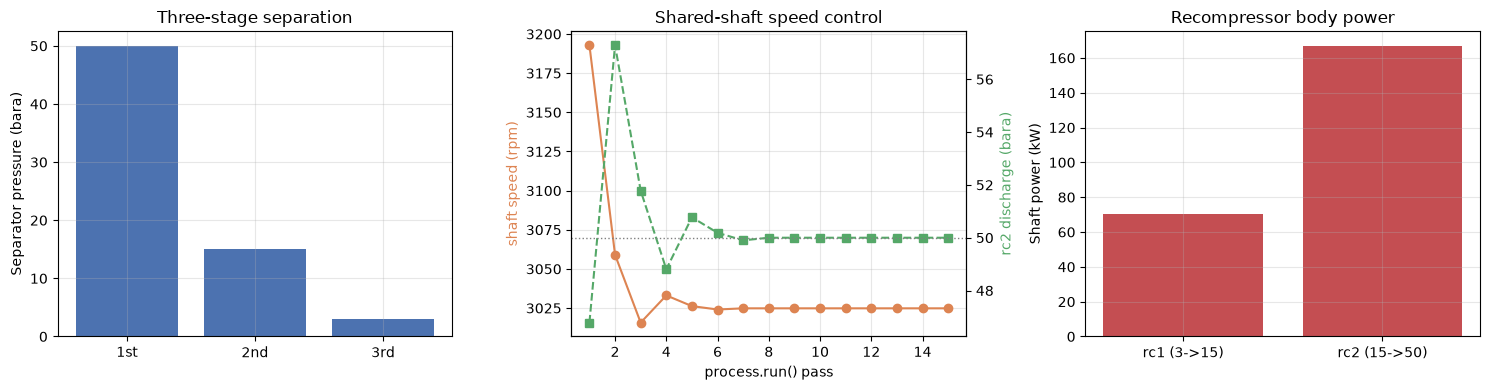

In [9]:
import matplotlib
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].bar(['1st', '2nd', '3rd'], [P1, P2, P3], color='#4C72B0')
axs[0].set_ylabel('Separator pressure (bara)'); axs[0].set_title('Three-stage separation'); axs[0].grid(alpha=0.3)

n = range(1, len(speeds) + 1)
axs[1].plot(n, speeds, 'o-', color='#DD8452', label='common speed')
ax1b = axs[1].twinx()
ax1b.plot(n, disch, 's--', color='#55A868', label='rc2 discharge')
ax1b.axhline(P1, color='grey', ls=':', lw=1)
axs[1].set_xlabel('process.run() pass'); axs[1].set_ylabel('shaft speed (rpm)', color='#DD8452')
ax1b.set_ylabel('rc2 discharge (bara)', color='#55A868')
axs[1].set_title('Shared-shaft speed control'); axs[1].grid(alpha=0.3)

axs[2].bar(['rc1 (3->15)', 'rc2 (15->50)'], [rc1.getPower() / 1e3, rc2.getPower() / 1e3], color='#C44E52')
axs[2].set_ylabel('Shaft power (kW)'); axs[2].set_title('Recompressor body power'); axs[2].grid(alpha=0.3)

fig.tight_layout(); plt.show()

## 9. Fixed-speed operation (constant-speed motor)

If the driver is a **constant-speed motor** (no variable-speed drive), the speed is **locked** and
is *not* a control degree of freedom. `runAtFixedSpeed(rpm, ...)` pins the speed on every body and
the discharge **floats** off the chart - you cannot set it directly. Sweeping the (fixed) speed
shows the discharge simply follows the map.

In [10]:
def _run_recompr():
    rc1.run(); interstage.run(); rc2.run()
run_sub = jpype.JProxy('java.lang.Runnable', dict(run=_run_recompr))

print('Fixed-speed sweep (rc2 discharge floats with speed):')
for rpm in (common * 0.95, common, common * 1.05):
    shaft.runAtFixedSpeed(float(rpm), run_sub)
    print('  locked %6.0f rpm  ->  rc2 discharge %6.1f bara'
          % (rpm, rc2.getOutletStream().getPressure('bara')))

Fixed-speed sweep (rc2 discharge floats with speed):
  locked   2850 rpm  ->  rc2 discharge   29.7 bara
  locked   3000 rpm  ->  rc2 discharge   46.8 bara
  locked   3150 rpm  ->  rc2 discharge   55.5 bara


## 10. Pressure-control options at fixed speed

With speed off the table, you control pressure/capacity another way. Every option below has a
runnable example in this notebook.

| Option | How it works | NeqSim | Example |
|---|---|---|---|
| **Variable speed (VSD)** | Move the common speed - the cleanest control. Not available on a fixed-speed motor. | `CompressorShaftCalculator` / `solveSpeed` | Sections 4-6 |
| **Downstream choke** | A let-down valve *after* the machine drops the surplus discharge to spec (throttles away head). | `ThrottlingValve` on the discharge | Section 10 |
| **Suction / upstream choke** | A valve *before* the machine lowers the suction, so the same speed makes a lower discharge. | `ThrottlingValve` on the suction | Section 10 |
| **Anti-surge recycle (ASV)** | Spill-back keeps the machine off surge at turndown; sets *minimum flow*, not the discharge. | `AntiSurgeRecycleCalculator` / `AntiSurgeCalculator` | Section 11 |
| **Inlet guide vanes (IGV)** | Pre-swirl reduces head & efficiency and lowers surge flow at fixed speed. | `setInletGuideVaneOpening` / `CompressorChartIGV` | Section 12 |

The two throttling options, at a locked speed:

In [11]:
# Lock the shaft at rated speed; the discharge floats.
shaft.runAtFixedSpeed(common, run_sub)
p_float = float(rc2.getOutletStream().getPressure('bara'))
print('Locked at %.0f rpm -> rc2 discharge floats to %.1f bara\n' % (common, p_float))

# Option A - DOWNSTREAM CHOKE: a let-down valve after rc2 drops the discharge to the export spec.
choke = ThrottlingValve('export let-down choke', rc2.getOutletStream())
choke.setOutletPressure(round(p_float - 5.0, 1)); choke.run()
print('Downstream choke:   %.1f -> %.1f bara (surplus head throttled away)'
      % (p_float, choke.getOutletStream().getPressure('bara')))

# Option B - SUCTION (UPSTREAM) THROTTLE on a self-contained fixed-speed machine:
# lowering the suction lowers the discharge at the SAME locked speed.
gas = SystemSrkEos(273.15 + 40.0, 20.0)
for nm, z in [('methane', 0.90), ('ethane', 0.07), ('propane', 0.03)]:
    gas.addComponent(nm, z)
gas.setMixingRule('classic')
s0 = Stream('demo suction', gas)
s0.setFlowRate(8000.0, 'kg/hr'); s0.setTemperature(40.0, 'C'); s0.setPressure(20.0, 'bara'); s0.run()
kdemo = Compressor('demo fixed-speed machine', s0)
kdemo.setOutletPressure(45.0); kdemo.setUsePolytropicCalc(True); kdemo.setPolytropicEfficiency(0.78); kdemo.run()
kdemo.generateCompressorChart('normal curves', 5); kdemo.getCompressorChart().setUseCompressorChart(True)
lock = float(kdemo.getSpeed())
print('\nSuction throttle at a fixed %.0f rpm (discharge drops with suction):' % lock)
for p_suc in (20.0, 17.0, 14.0):
    sv = ThrottlingValve('suction choke', s0); sv.setOutletPressure(p_suc); sv.run()
    k2 = Compressor('demo', sv.getOutletStream())
    k2.setCompressorChart(kdemo.getCompressorChart()); k2.setUsePolytropicCalc(True)
    k2.setSpeed(lock); k2.run()
    print('  suction %4.0f bara -> discharge %5.1f bara'
          % (p_suc, k2.getOutletStream().getPressure('bara')))

Locked at 3000 rpm -> rc2 discharge floats to 46.8 bara

Downstream choke:   46.8 -> 41.8 bara (surplus head throttled away)

Suction throttle at a fixed 3000 rpm (discharge drops with suction):
  suction   20 bara -> discharge  45.0 bara
  suction   17 bara -> discharge  35.2 bara
  suction   14 bara -> discharge  24.5 bara


## 11. Anti-surge control at fixed speed

At a fixed speed, reducing throughput (turndown) moves the operating point *left* toward the
**surge** line. An **anti-surge controller** opens a **recycle (spill-back) valve** so the
compressor's own inlet flow stays above the surge control line; the excess is cooled and returned
to the suction.

NeqSim offers three tools:

- **`AntiSurgeRecycleCalculator`** (used here) - a stable **steady-state** solver that computes the
  cooled recycle flow needed to hold the inlet a set margin above surge.
- **`AntiSurgeCalculator`** - a process-integrated controller that writes a recycle `Splitter` branch
  each `process.run()` pass (used inside a full recycle loop, e.g. platform models).
- **`AntiSurgeController`** - a dynamic PI controller for `runTransient` studies.

We hold a fixed-speed machine 5 % above surge and turn it down: the recycle opens as the feed drops.

In [12]:
def as_gas():
    fl = SystemSrkEos(273.15 + 40.0, 20.0)
    for nm, z in [('methane', 0.90), ('ethane', 0.07), ('propane', 0.03)]:
        fl.addComponent(nm, z)
    fl.setMixingRule('classic')
    return fl

suction = Stream('AS suction', as_gas())
suction.setFlowRate(20000.0, 'kg/hr'); suction.setTemperature(40.0, 'C'); suction.setPressure(20.0, 'bara'); suction.run()
kc = Compressor('fixed-speed compressor', suction)
kc.setOutletPressure(45.0); kc.setUsePolytropicCalc(True); kc.setPolytropicEfficiency(0.78); kc.run()
kc.generateCompressorChart('normal curves', 5); kc.getCompressorChart().setUseCompressorChart(True)
lock_rpm = float(kc.getSpeed())

as_rows = []
print('Fixed speed %.0f rpm; AntiSurgeRecycleCalculator holds the inlet 5%% above surge:' % lock_rpm)
for feed_rate in (20000.0, 14000.0, 10000.0, 7000.0):
    suction.setFlowRate(feed_rate, 'kg/hr'); suction.run()
    kc.setInletStream(suction)                 # reset to the natural (un-recycled) suction
    kc.setSpeed(lock_rpm); kc.setSolveSpeed(False); kc.run()
    calc = AntiSurgeRecycleCalculator(kc, suction)
    calc.setSurgeControlMargin(0.05)
    r = calc.solve()
    as_rows.append((feed_rate, float(r.getDistanceToSurge()), float(r.getRecycleMassFlow()), bool(r.isRecycleActive())))
    print('  feed %6.0f kg/hr -> dist-to-surge %+.3f  |  recycle %7.0f kg/hr  (%s)'
          % (feed_rate, r.getDistanceToSurge(), r.getRecycleMassFlow(),
             'recycling' if r.isRecycleActive() else 'no recycle'))

Fixed speed 3000 rpm; AntiSurgeRecycleCalculator holds the inlet 5% above surge:
  feed  20000 kg/hr -> dist-to-surge +0.491  |  recycle       0 kg/hr  (no recycle)
  feed  14000 kg/hr -> dist-to-surge +0.051  |  recycle    1945 kg/hr  (recycling)
  feed  10000 kg/hr -> dist-to-surge +0.052  |  recycle    5957 kg/hr  (recycling)
  feed   7000 kg/hr -> dist-to-surge +0.051  |  recycle    8945 kg/hr  (recycling)


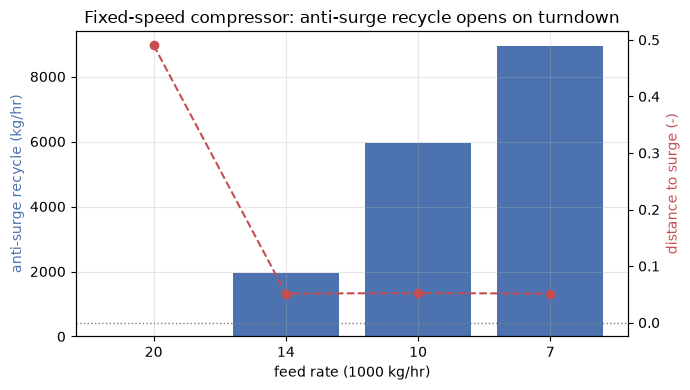

In [13]:
import matplotlib.pyplot as plt

feeds = [r[0] / 1000.0 for r in as_rows]
recyc = [r[2] for r in as_rows]
d2s = [r[1] for r in as_rows]
labels = [str(int(f)) for f in feeds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, recyc, color='#4C72B0')
ax.set_xlabel('feed rate (1000 kg/hr)'); ax.set_ylabel('anti-surge recycle (kg/hr)', color='#4C72B0')
axb = ax.twinx()
axb.plot(labels, d2s, 'o--', color='#C44E52')
axb.axhline(0.0, color='grey', ls=':', lw=1)
axb.set_ylabel('distance to surge (-)', color='#C44E52')
ax.set_title('Fixed-speed compressor: anti-surge recycle opens on turndown')
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

> **Key takeaway:** anti-surge sets a *minimum flow*, not the discharge. As the feed drops the
> recycle opens to keep the machine ~5 % right of surge (distance-to-surge held near 0.05).

## 12. Inlet guide vanes (IGV)

Closing the inlet guide vanes adds pre-swirl that, at a **fixed speed**, **reduces head and
efficiency and lowers the surge flow** (shifting the surge line left, which extends turndown).
NeqSim supports IGV two ways.

### 12a. Parametric model (`InletGuideVaneModel`)

Use this when you only have a fully-open chart. `setInletGuideVaneOpening(f)` (`f = 1` fully open)
applies generic, tunable corrections and is the validated end-to-end fixed-speed control.

In [14]:
gas2 = SystemSrkEos(273.15 + 40.0, 20.0)
for nm, z in [('methane', 0.90), ('ethane', 0.07), ('propane', 0.03)]:
    gas2.addComponent(nm, z)
gas2.setMixingRule('classic')
s_igv = Stream('IGV demo suction', gas2)
s_igv.setFlowRate(8000.0, 'kg/hr'); s_igv.setTemperature(40.0, 'C'); s_igv.setPressure(20.0, 'bara'); s_igv.run()
k_igv = Compressor('IGV demo machine', s_igv)
k_igv.setOutletPressure(45.0); k_igv.setUsePolytropicCalc(True); k_igv.setPolytropicEfficiency(0.78); k_igv.run()
k_igv.generateCompressorChart('normal curves', 5); k_igv.getCompressorChart().setUseCompressorChart(True)
k_igv.setSolveSpeed(False)
rated_igv = float(k_igv.getSpeed()); k_igv.setSpeed(rated_igv)   # FIXED shaft speed

print('Parametric IGV at a FIXED shaft speed of %.0f rpm:' % rated_igv)
print('  IGV%    discharge    poly-eff    surge-flow      dist-to-surge')
for igv in (1.0, 0.9, 0.8, 0.7):
    k_igv.setInletGuideVaneOpening(igv)
    k_igv.run()
    print('  %3.0f%%   %7.1f bara   %6.1f%%    %8.0f m3/hr    %+.3f'
          % (igv * 100, k_igv.getOutletStream().getPressure('bara'),
             k_igv.getPolytropicEfficiency() * 100.0, k_igv.getSurgeFlowRate(), k_igv.getDistanceToSurge()))
k_igv.setInletGuideVaneOpening(1.0)

Parametric IGV at a FIXED shaft speed of 3000 rpm:
  IGV%    discharge    poly-eff    surge-flow      dist-to-surge
  100%      45.0 bara     76.8%         377 m3/hr    +0.491
   90%      43.0 bara     76.0%         338 m3/hr    +0.660
   80%      41.1 bara     75.2%         311 m3/hr    +0.803
   70%      39.3 bara     74.4%         293 m3/hr    +0.916


### 12b. Vendor IGV-position maps (`CompressorChartIGV`)

When a vendor supplies a **full performance map per vane position**, `CompressorChartIGV`
interpolates them into a `CompressorChart` at any opening (regenerating the surge curve). Attach it
with `comp.setInletGuideVaneChart(family)` to drive the active chart per opening.

In [15]:
def _jd(a):
    return jpype.JArray(jpype.JDouble)([float(x) for x in a])
def _jd2(a):
    return jpype.JArray(jpype.JDouble, 2)([_jd(r) for r in a])

cc = _jd([30.0, 20.0]); spd = _jd([8000.0, 10000.0, 12000.0])
flw = _jd2([[1000, 1500, 2000], [1300, 1800, 2300], [1600, 2100, 2600]])
h_open = _jd2([[60, 55, 46], [90, 83, 70], [125, 115, 98]])   # fully-open vendor map
h_half = _jd2([[42, 38, 32], [63, 58, 49], [88, 80, 69]])     # half-open vendor map
ef = _jd2([[.74, .80, .75], [.75, .81, .76], [.74, .80, .75]])

family = CompressorChartIGV(); family.setHeadUnit('kJ/kg')
family.addPosition(1.0, cc, spd, flw, h_open, ef)   # fully open
family.addPosition(0.5, cc, spd, flw, h_half, ef)   # half open

print('Vendor IGV-position chart family, head at (flow 1500 m3/hr, speed 10000 rpm):')
for f in (1.0, 0.75, 0.5):
    ch = family.getChartAtOpening(f)
    print('  IGV %3.0f%% open -> interpolated chart head %5.1f kJ/kg'
          % (f * 100, ch.getPolytropicHead(1500.0, 10000.0)))

Vendor IGV-position chart family, head at (flow 1500 m3/hr, speed 10000 rpm):
  IGV 100% open -> interpolated chart head  86.6 kJ/kg
  IGV  75% open -> interpolated chart head  73.5 kJ/kg
  IGV  50% open -> interpolated chart head  60.5 kJ/kg


> **Key takeaway:** IGV keeps the *shaft speed fixed* yet also **shifts the surge line** - so
> anti-surge sees the correct margin. Use `InletGuideVaneModel` for screening and
> `CompressorChartIGV` when you have real per-position vendor maps.

## 13. Recap

| Concept | NeqSim tool | Section |
|---|---|---|
| Shared shaft = 1 speed = 1 pressure target; intermediates float | `CompressorShaft` | 1, 4 |
| Converge the common speed inside `run()` | `CompressorShaftCalculator` | 4 |
| Is the duty possible? achievable window + reason | `getLastSolveResult()` / `isFeasible()` | 5 |
| Shed surplus head for a too-low target | `setPressureControl(...)` | 6 |
| Surface an unmet pressure at a mixing node | `Mixer.isPressureMismatch()` | 7 |
| Fixed speed: discharge floats | `runAtFixedSpeed(...)` | 9 |
| Downstream / suction choke | `ThrottlingValve` | 10 |
| Anti-surge recycle at turndown | `AntiSurgeRecycleCalculator` | 11 |
| Inlet guide vanes (parametric / vendor maps) | `InletGuideVaneModel` / `CompressorChartIGV` | 12 |

### The one rule to remember

A shared shaft has **one** speed and **one** pressure target - control that final discharge with
speed (VSD) when you can, and with a choke, recycle or IGV when the speed is fixed. Always check
**feasibility** before trusting a result.

### Where to go next

- Reference: `docs/process/equipment/compressor_shaft.md` and
  `docs/process/equipment/compressor_curves.md` (IGV section).
- Anti-surge and coordinated control: `docs/process/equipment/compressor_antisurge_control.md`.

### Try it yourself

1. Change the feed rate in Section 3 and re-run - does the shaft stay feasible?
2. In Section 5, ask for a target just below `p_max` - feasible or not?
3. In Section 11, push the turndown to 5000 kg/hr - how much recycle is needed?
4. In Section 12, tune `k_igv.getInletGuideVaneModel().setSurgeFlowDrop(...)` and watch the
   distance-to-surge change.